In [ ]:
# R2419465
# Sophia G Chikoto

# Definition (Technical Framework)
## Xt​∼I(1),Yt​∼I(1)
## These series are said to be cointegrated if there exists a linear combination:
## Zt​=Yt​−βXt​
## such that:
## Zt​∼I(0)

## That is, although Xt and Yt are individually non-stationary, their linear combination is stationary.
## The long-run relationship is estimated using:
## Yt​=α+βXt​+ϵt​

# where:
## •α is the intercept 
## •β measures the long-run relationship 
## •ϵt represents deviations from equilibrium 
## To capture short-run dynamics, the Error Correction Model (ECM) is used:

## ΔYt​=γ(Yt−1​−βXt−1​)+δΔXt​+ut​

# where:
## •γ is the speed of adjustment toward equilibrium 
## •δ captures short-run effects 
## •Y(t-1) – βX(t-1) is the lagged equilibrium error

# Description
# Cointegration models identify stable, long-term relationships between variables that individually follow non-stationary processes. Even though each series may drift over time, their combination can remain stable, indicating an equilibrium relationship

# Demonstration
## The analysis begins by importing and structuring the data using Python. Missing values are removed, and the time series are plotted to visually inspect their behavior. Both series display upward trends, suggesting non-stationarity.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm

# Plot settings
plt.style.use('default')

In [2]:
stocks = ['AAPL', 'MSFT']
data = yf.download(stocks, start='2018-01-01', end='2025-12-31')['Close']

data.dropna(inplace=True)

data.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,MSFT
Date,,
2018-01-02,40.304165,78.870354
2018-01-03,40.297157,79.237411
2018-01-04,40.484341,79.934807
2018-01-05,40.945274,80.925827
2018-01-08,40.793171,81.008453


<Figure size 640x480 with 0 Axes>

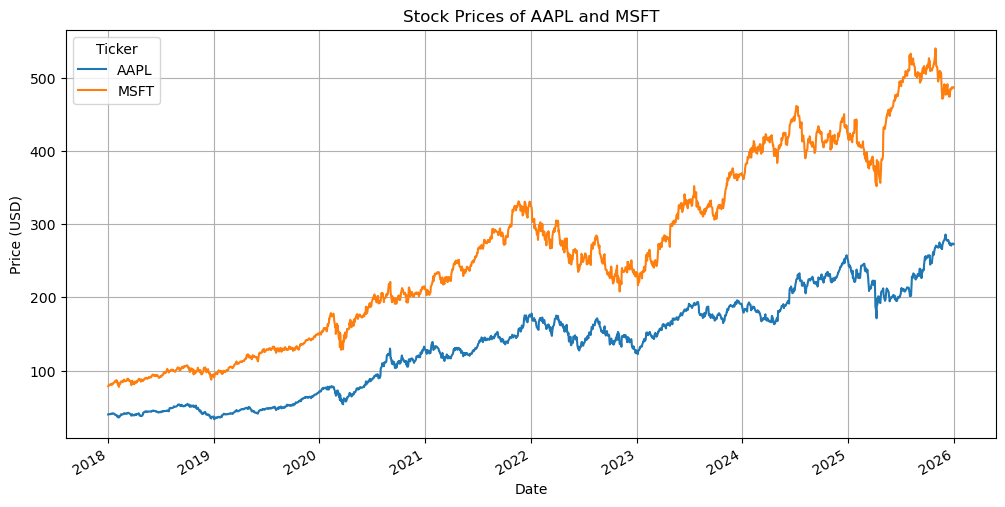

In [3]:
# Plot stock prices
plt.figure()
data.plot(figsize=(12,6))
plt.title("Stock Prices of AAPL and MSFT")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid()
plt.show()

In [4]:
def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}")
    print(f"Test Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("Conclusion:", "Stationary" if result[1] < 0.05 else "Non-Stationary")
    print("-"*50)

# Apply ADF test
adf_test(data['AAPL'], 'AAPL')
adf_test(data['MSFT'], 'MSFT')

ADF Test for AAPL
Test Statistic: -0.24837530024940993
p-value: 0.9325043653203935
Conclusion: Non-Stationary
--------------------------------------------------
ADF Test for MSFT
Test Statistic: -0.41860714656658515
p-value: 0.9069453882528486
Conclusion: Non-Stationary
--------------------------------------------------


In [5]:
score, pvalue, _ = coint(data['AAPL'], data['MSFT'])

print("Cointegration Test Results")
print("Test Statistic:", score)
print("p-value:", pvalue)
print("p-value:", pvalue>0.05)

Cointegration Test Results
Test Statistic: -3.260133665342717
p-value: 0.060433828263154604
p-value: True


In [6]:
X = sm.add_constant(data['MSFT'])
y = data['AAPL']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                 2.779e+04
Date:                Fri, 08 May 2026   Prob (F-statistic):               0.00
Time:                        14:14:09   Log-Likelihood:                -8583.1
No. Observations:                2010   AIC:                         1.717e+04
Df Residuals:                    2008   BIC:                         1.718e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1870      0.898      0.208      0.8

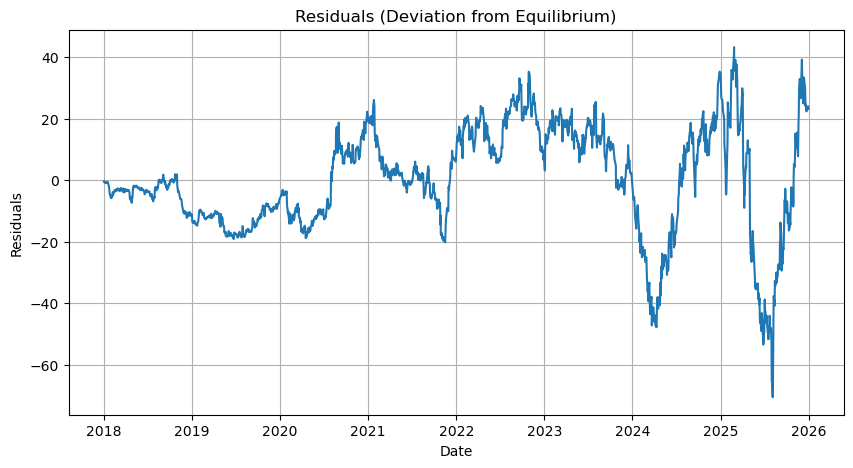

In [7]:
residuals = model.resid

# Plot residuals
plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals (Deviation from Equilibrium)")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid()
plt.show()

In [8]:
adf_test(residuals, 'Residuals')

ADF Test for Residuals
Test Statistic: -3.257107505443402
p-value: 0.016908076538021913
Conclusion: Stationary
--------------------------------------------------


In [9]:
data['residuals_lag'] = residuals.shift(1)
data['dAAPL'] = data['AAPL'].diff()
data['dMSFT'] = data['MSFT'].diff()

data.dropna(inplace=True)

X_ecm = sm.add_constant(pd.concat([data['dMSFT'], data['residuals_lag']], axis=1))
y_ecm = data['dAAPL']

ecm_model = sm.OLS(y_ecm, X_ecm).fit()

print(ecm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  dAAPL   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     541.5
Date:                Fri, 08 May 2026   Prob (F-statistic):          9.07e-189
Time:                        14:14:09   Log-Likelihood:                -4350.5
No. Observations:                2009   AIC:                             8707.
Df Residuals:                    2006   BIC:                             8724.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0465      0.047      0.985

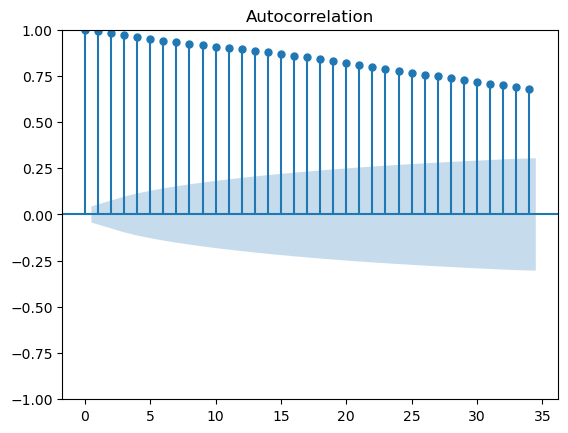

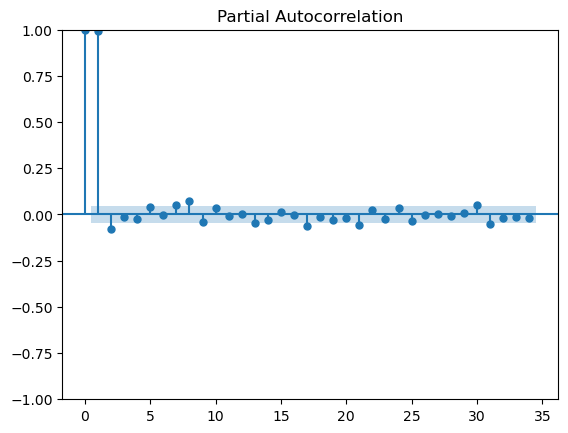

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(residuals)
plt.show()

plot_pacf(residuals)
plt.show()

# INTERPRETATION
## β (beta coefficient)
## Shows long-run relationship

# Example:
## “A 1-unit increase in MSFT leads to β increase in AAPL”

# Residuals
## Represent deviation from equilibrium

# γ (error correction term)
## If negative and significant:
## System returns to equilibrium
## Speed of adjustment

# DAMAGE (Problems Found)

## Presence of volatility clustering
## Structural breaks (COVID period)
## Possible omitted variables
## Nonlinear relationships

# DIRECTIONS (Improvement)

## Remove outliers
## Use log prices
## Shorten time horizon
## Try Johansen test
## Include more variables

# DEPLOYMENT

## Portfolio hedging
## Pairs trading strategy
## Risk management
## Arbitrage opportunities

# References (MLA Format)
## •	Engle, Robert F., and Clive W. J. Granger. “Co-Integration and Error Correction: Representation, Estimation, and Testing.” Econometrica, vol. 55, no. 2, 1987, pp. 251–276. 
## •	Hamilton, James D. Time Series Analysis. Princeton University Press, 1994. 
## •	Data retrieved from Yahoo Finance
